# Event Exploration (Security)

Parsing the data and understanding it (EventData attribute)

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from anomaly_detection.etl.load import load_records, load_eventdata_df, load_eventdata
from anomaly_detection.utils.profile_eventdata import profile_all, print_summary, summarize_constants, export_profiles_csv

plt.style.use('ggplot')

In [2]:
# Path to the data
project_folder = Path.cwd().parent

output_path = project_folder / "data/event_exploration/security"

evtx_path = project_folder / "data/raw/93_securitelog.evtx"

evtx_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/raw/93_securitelog.evtx')

In [3]:
records = load_records(evtx_path)

len(records)

31466

In [4]:
with open(project_folder / "data/processed/record.txt", "w", encoding="utf-8") as file:
    file.write(json.dumps(
        records[0],
        indent=4
    ))

records[0]

{'#attributes': {'xmlns': 'http://schemas.microsoft.com/win/2004/08/events/event'},
 'System': {'Provider': {'Name': 'Microsoft-Windows-Security-Auditing',
   'Guid': '54849625-5478-4994-A5BA-3E3B0328C30D'},
  'EventID': 4624,
  'Version': 2,
  'Level': 0,
  'Task': 12544,
  'Opcode': 0,
  'Keywords': '0x8020000000000000',
  'TimeCreated': {'SystemTime': '2026-06-17T00:15:07.799161Z'},
  'EventRecordID': 34978816,
  'Correlation': {'ActivityID': 'F1DAB952-E970-0004-5DB9-DAF170E9DC01'},
  'Execution': {'ProcessID': 940, 'ThreadID': 5960},
  'Channel': 'Security',
  'Computer': 'ESANTE.carte.com.tn',
  'Security': None},
 'EventData': {'SubjectUserSid': 'S-1-5-18',
  'SubjectUserName': 'ESANTE$',
  'SubjectDomainName': 'CARTE',
  'SubjectLogonId': '0x3e7',
  'TargetUserSid': 'S-1-5-21-3333335972-2113272682-612058519-500',
  'TargetUserName': 'Administrateur',
  'TargetDomainName': 'ESANTE',
  'TargetLogonId': '0x77061c91',
  'LogonType': 4,
  'LogonProcessName': 'Advapi  ',
  'Authentica

In [5]:
from anomaly_detection.utils.extract_shared_features import extract_specific_events

res = extract_specific_events(["35010094"], evtx_path)

res

[{'timestamp': datetime.datetime(2026, 6, 17, 9, 48, 35, 862498, tzinfo=datetime.timezone.utc),
  'data': {'@xmlns': 'http://schemas.microsoft.com/win/2004/08/events/event',
   'System': {'Provider': {'@Name': 'Microsoft-Windows-Security-Auditing',
     '@Guid': '54849625-5478-4994-A5BA-3E3B0328C30D'},
    'EventID': 4611,
    'Version': '0',
    'Level': '0',
    'Task': '12289',
    'Opcode': '0',
    'Keywords': '0x8020000000000000',
    'TimeCreated': {'@SystemTime': '2026-06-17T09:48:35.574661Z'},
    'EventRecordID': '35010094',
    'Correlation': {'@ActivityID': 'F1DAB952-E970-0004-5DB9-DAF170E9DC01'},
    'Execution': {'@ProcessID': '940', '@ThreadID': '6200'},
    'Channel': 'Security',
    'Computer': 'ESANTE.carte.com.tn',
    'Security': None},
   'EventData': {'SubjectUserSid': 'S-1-5-18',
    'SubjectUserName': 'ESANTE$',
    'SubjectDomainName': 'CARTE',
    'SubjectLogonId': '0x3e7',
    'LogonProcessName': 'UserManager'}}}]

In [6]:
event_df = load_eventdata_df(evtx_path)

event_df.head()

,EventID,EventRecordID,TimeCreated,PayloadSource,SubjectUserSid,SubjectUserName,SubjectDomainName,SubjectLogonId,LogonProcessName,TargetUserSid,...,KeyName,KeyType,KeyFilePath,Operation,ReturnCode,TargetName,Type,CountOfCredentialsReturned,ReadOperation,ProcessCreationTime
0,4611,35010093,2026-06-17T09:48:35.572564Z,EventData,S-1-5-18,ESANTE$,CARTE,0x3e7,Winlogon,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4611,35010094,2026-06-17T09:48:35.574661Z,EventData,S-1-5-18,ESANTE$,CARTE,0x3e7,UserManager,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4611,35010098,2026-06-17T09:48:35.862661Z,EventData,S-1-5-18,ESANTE$,CARTE,0x3e7,UserManager,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4624,34978816,2026-06-17T00:15:07.799161Z,EventData,S-1-5-18,ESANTE$,CARTE,0x3e7,Advapi,S-1-5-21-3333335972-2113272682-612058519-500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4624,34978822,2026-06-17T00:16:00.615964Z,EventData,S-1-5-18,ESANTE$,CARTE,0x3e7,.UBPM,S-1-5-21-3333335972-2113272682-612058519-500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
event_df.columns

Index(['EventID', 'EventRecordID', 'TimeCreated', 'PayloadSource',
       'SubjectUserSid', 'SubjectUserName', 'SubjectDomainName',
       'SubjectLogonId', 'LogonProcessName', 'TargetUserSid', 'TargetUserName',
       'TargetDomainName', 'TargetLogonId', 'LogonType',
       'AuthenticationPackageName', 'WorkstationName', 'LogonGuid',
       'TransmittedServices', 'LmPackageName', 'KeyLength', 'ProcessId',
       'ProcessName', 'IpAddress', 'IpPort', 'ImpersonationLevel',
       'RestrictedAdminMode', 'TargetOutboundUserName',
       'TargetOutboundDomainName', 'VirtualAccount', 'TargetLinkedLogonId',
       'ElevatedToken', 'TargetLogonGuid', 'TargetServerName', 'TargetInfo',
       'ObjectServer', 'ObjectType', 'ObjectName', 'OperationType', 'HandleId',
       'AccessList', 'AccessMask', 'Properties', 'AdditionalInfo',
       'AdditionalInfo2', 'PrivilegeList', 'ServiceName', 'ServiceFileName',
       'ServiceType', 'ServiceStartType', 'ServiceAccount',
       'ClientProcessStartKey'

In [ ]:
counts = event_df["EventID"].value_counts()

min_frequency = 1000

frequent = counts[counts >= min_frequency]
others = counts[counts < min_frequency]

In [10]:
event_descriptions = {
    4624: "Successful logon",
    4776: "Credential validation",
    4672: "Special privileges",
    4634: "Logoff",
    4648: "Explicit credentials",
}

frequent.index = [
    f"{eid}: {event_descriptions.get(eid, 'Unknown')}"
    if isinstance(eid, int) else eid
    for eid in frequent.index
]

other_label = f""
frequent[other_label] = others.sum()

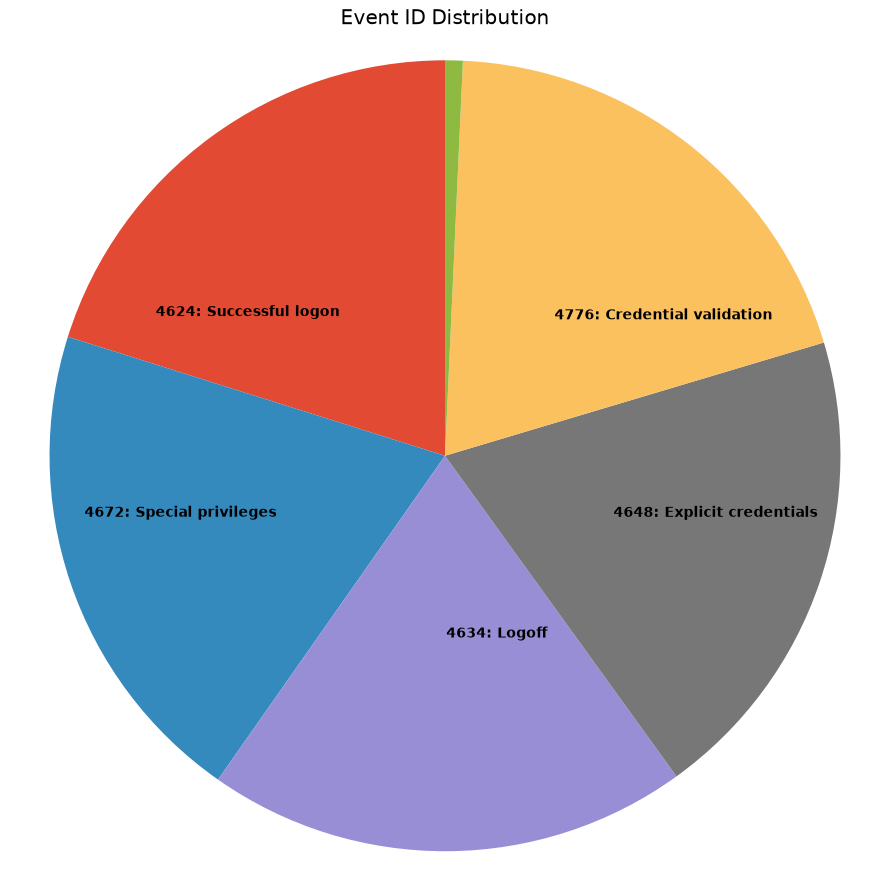

In [15]:
fig, ax = plt.subplots(figsize=(9, 9))

wedges, label_texts = ax.pie(
    frequent.values,
    labels=frequent.index,
    startangle=90,
    labeldistance=0.45,
)

# Make EventIDs bold
for t in label_texts:
    t.set_fontweight("bold")
    t.set_fontsize(10)

ax.set_title("Event ID Distribution")
ax.axis("equal")
plt.tight_layout()

plt.savefig(output_path / "event_id_distribution.png")

plt.show()

In [175]:
event_dfs = load_eventdata(evtx_path)

In [176]:
profiles = profile_all(event_dfs)

export_profiles_csv(profiles, output_path)

In [177]:
from contextlib import redirect_stdout

with open(output_path / 'profile_summary.txt', 'w') as f:
    with redirect_stdout(f):
        print_summary(profiles, event_dfs)

print_summary(profiles, event_dfs)


EventID 4611 (3 records)
  constant  : ['SubjectUserSid', 'SubjectUserName', 'SubjectDomainName', 'SubjectLogonId']
  >=95% null: -
  variable  : ['LogonProcessName']

EventID 4624 (6336 records)
  constant  : ['TransmittedServices', 'ImpersonationLevel', 'TargetOutboundUserName', 'TargetOutboundDomainName']
  >=95% null: -
  variable  : ['SubjectUserSid', 'SubjectUserName', 'SubjectDomainName', 'SubjectLogonId', 'TargetUserSid', 'TargetUserName', 'TargetDomainName', 'TargetLogonId', 'LogonType', 'LogonProcessName', 'AuthenticationPackageName', 'WorkstationName', 'LogonGuid', 'LmPackageName', 'KeyLength', 'ProcessId', 'ProcessName', 'IpAddress', 'IpPort', 'RestrictedAdminMode', 'VirtualAccount', 'TargetLinkedLogonId', 'ElevatedToken']

EventID 4634 (6194 records)
  constant  : -
  >=95% null: -
  variable  : ['TargetUserSid', 'TargetUserName', 'TargetDomainName', 'TargetLogonId', 'LogonType']

EventID 4648 (6189 records)
  constant  : ['SubjectUserSid', 'SubjectUserName', 'SubjectDoma

In [178]:
constants = summarize_constants(profiles, event_dfs)

clean_constants = {int(k): v for k, v in constants.items()}

with open(output_path / 'constants.txt', 'w') as f:
    f.write(json.dumps(clean_constants, indent=4, default=int))

clean_constants

{4611: {'SubjectUserSid': 'S-1-5-18',
  'SubjectUserName': 'ESANTE$',
  'SubjectDomainName': 'CARTE',
  'SubjectLogonId': '0x3e7'},
 4624: {'TransmittedServices': '-',
  'ImpersonationLevel': '%%1833',
  'TargetOutboundUserName': '-',
  'TargetOutboundDomainName': '-'},
 4634: {},
 4648: {'SubjectUserSid': 'S-1-5-18',
  'SubjectUserName': 'ESANTE$',
  'SubjectDomainName': 'CARTE',
  'SubjectLogonId': '0x3e7',
  'LogonGuid': '00000000-0000-0000-0000-000000000000'},
 4662: {'SubjectUserName': 'ESANTE$',
  'SubjectDomainName': 'CARTE',
  'ObjectServer': 'WMI',
  'ObjectType': 'WMI Namespace',
  'OperationType': 'Object Access',
  'HandleId': '0x0',
  'AccessList': '%%1552\r\n\t\t\t\t',
  'AccessMask': '0x1',
  'Properties': '-'},
 4672: {},
 4697: {'SubjectUserSid': 'S-1-5-18',
  'SubjectUserName': 'ESANTE$',
  'SubjectDomainName': 'CARTE',
  'SubjectLogonId': '0x3e7',
  'ServiceType': '0xe0',
  'ServiceAccount': 'LocalSystem',
  'ClientProcessStartKey': np.int64(14636698788954177),
  'Cl